# Credit-G Decision Tree

In [1]:
import pandas as pd
from scipy.io import arff
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
data, meta = arff.loadarff('dataset_31_credit-g.arff')

df = pd.DataFrame(data)

for col in df.columns:
    if df[col].dtype == 'object':
        try:
            df[col] = df[col].str.decode('utf-8')
        except:
            pass

df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


In [3]:
X = df.drop(columns=['class'])
y = df['class']

# Encode categorical features
le = LabelEncoder()
X_encoded = X.copy()
for col in X_encoded.select_dtypes(include=['object']).columns:
    X_encoded[col] = le.fit_transform(X_encoded[col])

y_encoded = le.fit_transform(y)
class_names = le.classes_

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.3, random_state=42)

## Depth-Limited Tree (max_depth=5)

In [5]:
clf_5 = DecisionTreeClassifier(max_depth=5, random_state=42)
clf_5.fit(X_train, y_train)
y_pred_5 = clf_5.predict(X_test)

print(f"Train accuracy: {accuracy_score(y_train, clf_5.predict(X_train)):.4f}")
print(f"Test accuracy:  {accuracy_score(y_test, y_pred_5):.4f}")

Train accuracy: 0.8100
Test accuracy:  0.7167


In [6]:
print(f"Precision: {precision_score(y_test, y_pred_5):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_5):.4f}")

Precision: 0.8010
Recall:    0.7895


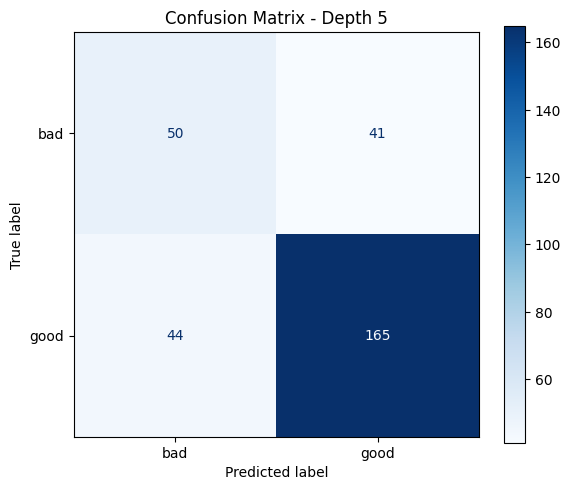

In [7]:
cm_5 = confusion_matrix(y_test, y_pred_5)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_5, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix - Depth 5')
plt.tight_layout()
plt.show()

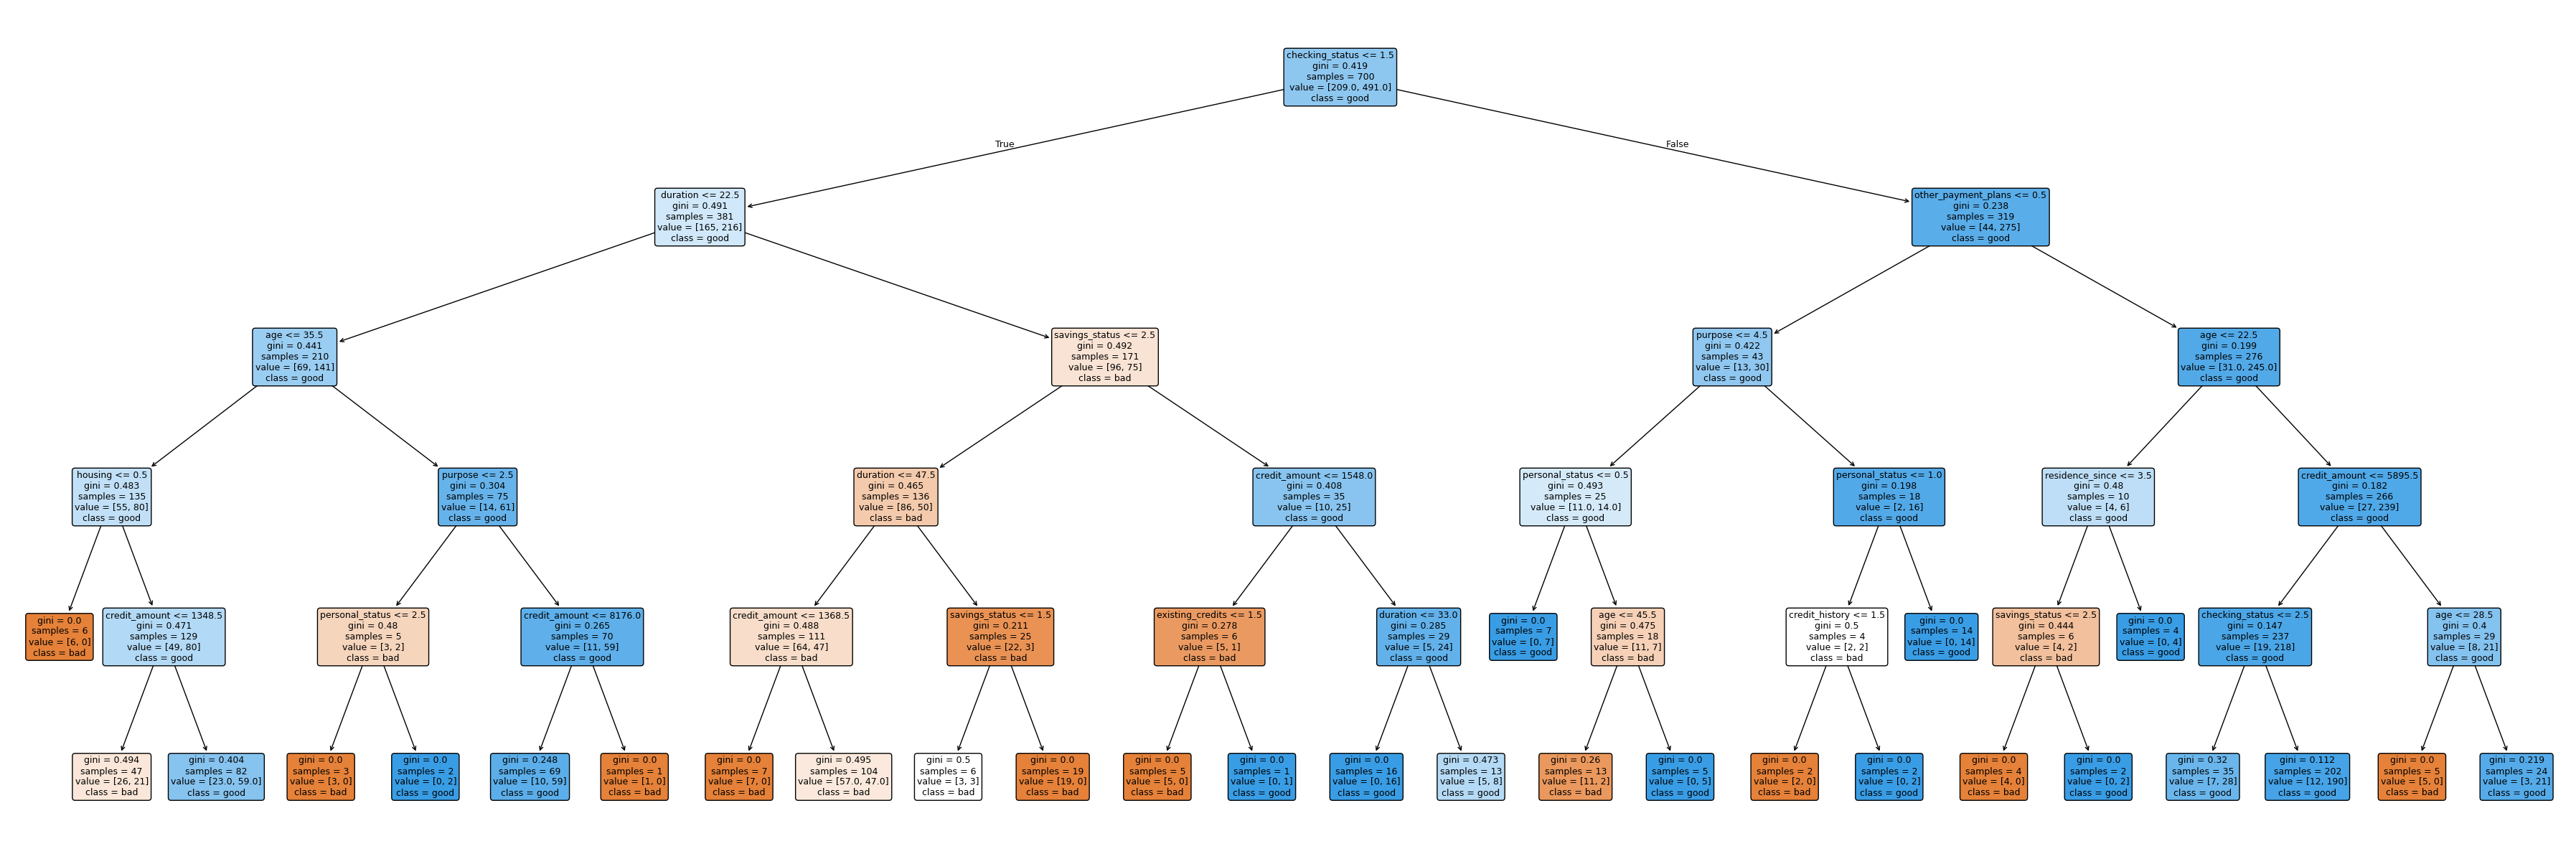

In [8]:
fig, ax = plt.subplots(figsize=(36, 12))
plot_tree(clf_5, feature_names=X_encoded.columns.tolist(), class_names=class_names, filled=True, rounded=True, fontsize=9, ax=ax)
plt.tight_layout()
plt.savefig('decision_tree_depth5.png', dpi=150, bbox_inches='tight')
plt.show()

## Depth-Limited Tree (max_depth=3)

In [9]:
clf_d3 = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_d3.fit(X_train, y_train)
y_pred_d3 = clf_d3.predict(X_test)

print(f"Train accuracy: {accuracy_score(y_train, clf_d3.predict(X_train)):.4f}")
print(f"Test accuracy:  {accuracy_score(y_test, y_pred_d3):.4f}")

Train accuracy: 0.7529
Test accuracy:  0.7367


In [10]:
print(f"Precision: {precision_score(y_test, y_pred_d3):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_d3):.4f}")

Precision: 0.7708
Recall:    0.8852


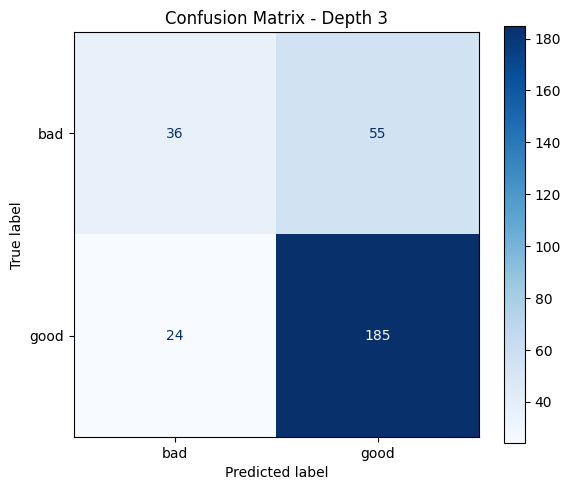

In [11]:
cm_d3 = confusion_matrix(y_test, y_pred_d3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_d3, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix - Depth 3')
plt.tight_layout()
plt.show()

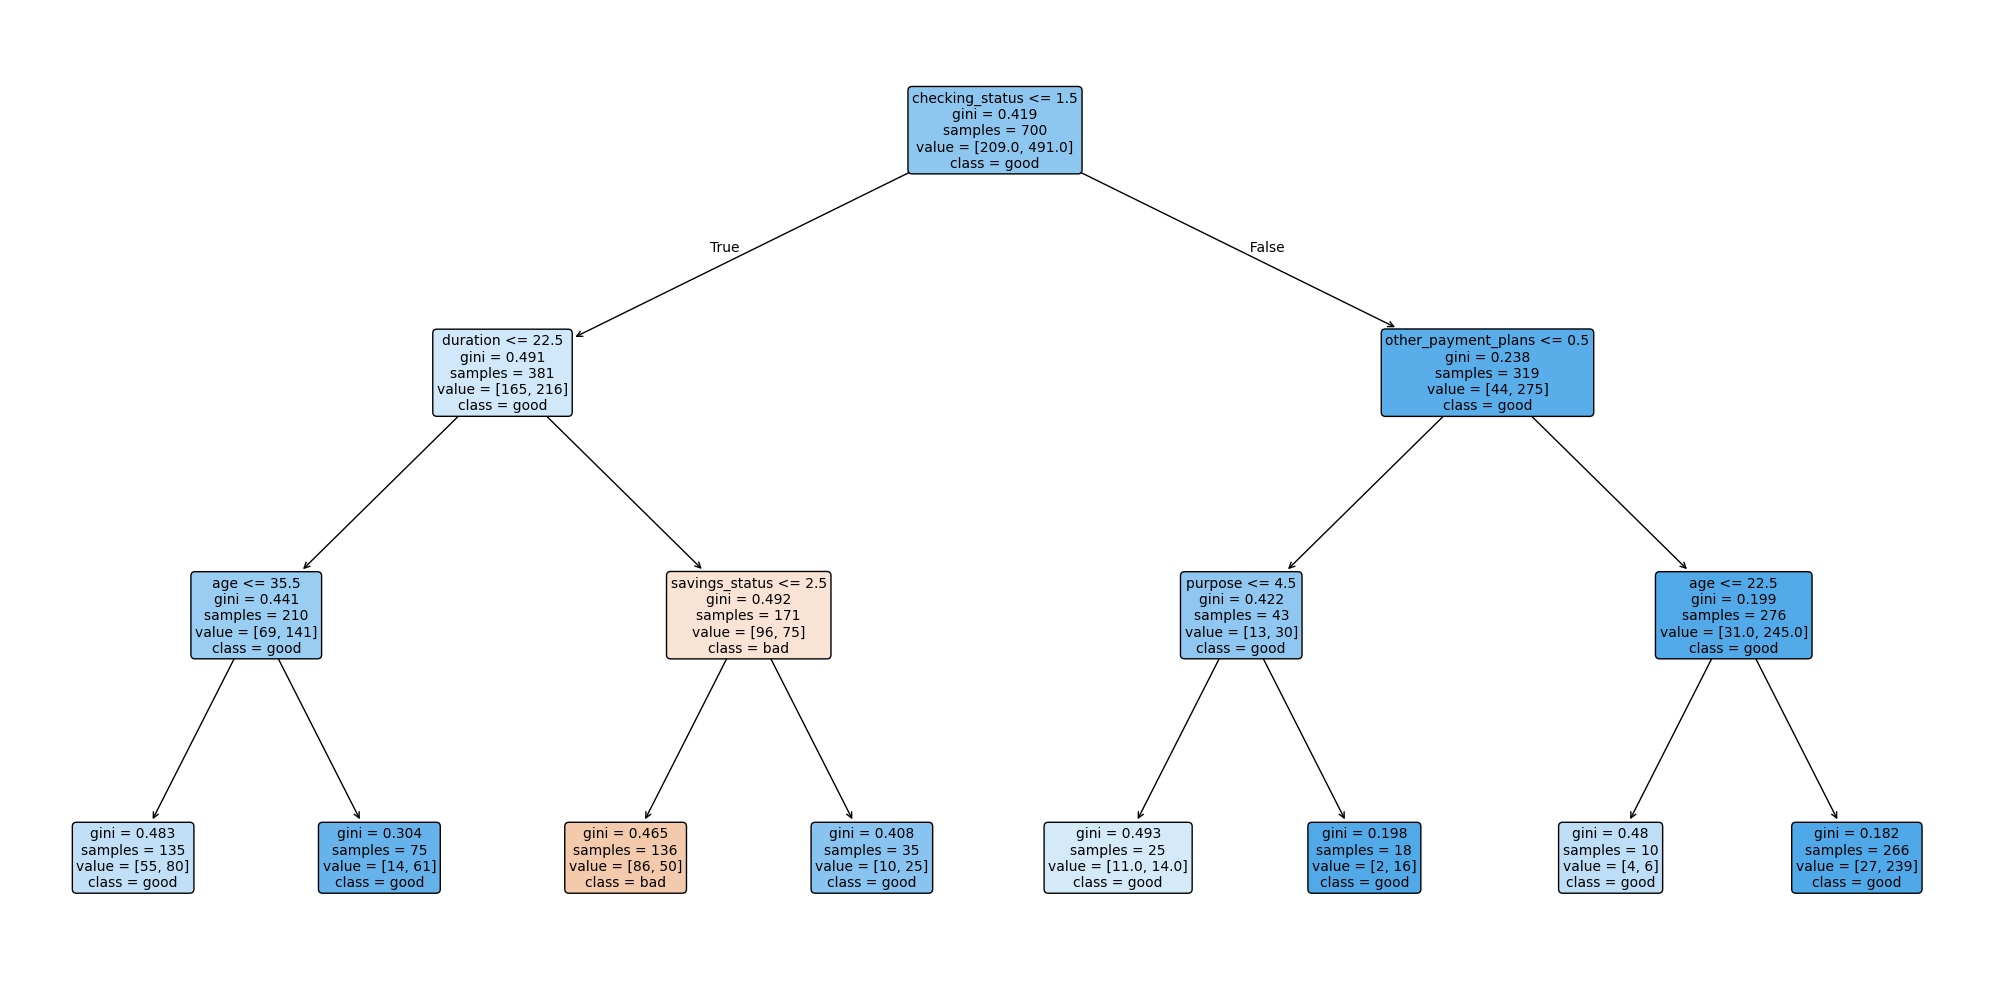

In [12]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(clf_d3, feature_names=X_encoded.columns.tolist(), class_names=class_names, filled=True, rounded=True, fontsize=10, ax=ax)
plt.tight_layout()
plt.savefig('decision_tree_depth3.png', dpi=150, bbox_inches='tight')
plt.show()